In [1]:
import os
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langchain_tavily import TavilySearch
load_dotenv()

/Users/akashdeepsangwan/Desktop/Code/GenAI/AgenticAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
api_key = os.getenv("claudeAPI")

llm = ChatAnthropic(
    model = "claude-haiku-4-5-20251001",
    api_key= api_key
)

In [3]:
tavily_tool = TavilySearch(
       tavily_api_key=os.getenv("tavilyAPI"),  
       max_results=5
   )

In [4]:
from typing import Annotated, List
from langchain_tavily import TavilySearch
from langchain_core.tools import StructuredTool
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader



from langgraph.graph import StateGraph, START, END

In [5]:
Embeddings = HuggingFaceEmbeddings(
    model_name  = "sentence-transformers/all-MiniLM-L6-v2"
)

In [6]:
def make_retriever_tool_from_text(file, name, desc) :
    docs = TextLoader(file, encoding= "utf-8").load()
    chunks = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap = 50).split_documents(docs)
    vs  = FAISS.from_documents(chunks, Embeddings)
    retriever = vs.as_retriever()

    
    def tool_func(query : str) -> str :
        print(f"Using tool : {name}")
        result = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in result)

    return StructuredTool.from_function( name = name, description= desc, func = tool_func)



internal_tool_1 = make_retriever_tool_from_text("/Users/akashdeepsangwan/Desktop/Code/GenAI/AgenticAI/MultiAgentRAG/research_notes.txt",
                                                "retriever_tool", "retrieves the document"
                                            )
internal_tool_1


StructuredTool(name='retriever_tool', description='retrieves the document', args_schema=<class 'langchain_core.utils.pydantic.retriever_tool'>, func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x124a7a5c0>)

### Command
- In langraph it is used for dynamic routing and controlling which node runs next.
- It replaces fixed edges with runtime decisions

-- it let next node to run or (END)

In [7]:
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState, END
from langgraph.types import Command

def get_next_node(last_message : BaseMessage, goto : str) :
    if "FINAL ANSWER" in last_message.content  :
        # Any agent decided the work is done
        return END
    return goto


In [8]:
def make_system_prompt(suffix : str) -> str :
    return(
        "You are a helpful AI assistant, collaborating with other assistants."
        "Use the provided tools to progress towards answering the question"
        "If you are unable to fully answer, that's OK, use another assistant with different tools"
        "Will help where you left off. Execute where you can to make progress."
        "If you or nay of the other assitants have the final answer or deliverable"
        "prefix you response with FINAL ANSWER so the team knows to stop"
        f"\n{suffix}"
    )

/var/folders/58/7rk_l2gn3lv73f_nlj98yjgc0000gn/T/ipykernel_4136/1668823114.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(


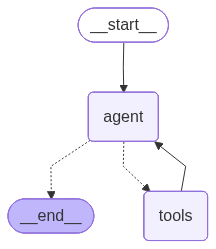

In [9]:
## Research Agent and Node
research_agent = create_react_agent(
    llm,
    tools = [internal_tool_1, tavily_tool],
    prompt = make_system_prompt("You can only do research. Use the tool that you are binded with, you can use both of them")
)

research_agent

In [10]:
from typing import Literal
## Research Node
def research_node(state : MessagesState) -> Command[Literal['blog_generator', END]] :
    result = research_agent.invoke(state)
    goto  = get_next_node(result["messages"][-1], "blog_generator")
    
    result['messages'][-1] = HumanMessage(
        
        content = result["messages"][-1].content, name = "researcher"
    )

    return Command(
        update = {
            "messages" : result['messages']
        }, goto=goto,
    )
    

In [11]:
# Blog write agent
blog_agent = create_react_agent(
    llm, tools = [tavily_tool],
    prompt = make_system_prompt("You can only write a detailed blog. You are working with a researcher colleague.")
)



def blog_node(state : MessagesState) -> Command[Literal['researcher', END]] :
    result = blog_agent.invoke(state)
    goto= get_next_node(result["messages"][-1], "researcher")

    result['messages'][-1] = HumanMessage(
        content = result['messages'][-1].content, name = "blog_generator"
    )
    
    return Command(
        update = {
            "messages" : result["messages"]
        }, 
        goto = goto
    )


/var/folders/58/7rk_l2gn3lv73f_nlj98yjgc0000gn/T/ipykernel_4136/515743835.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  blog_agent = create_react_agent(


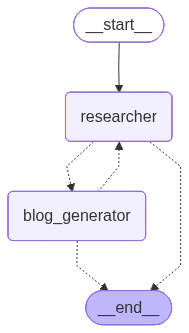

In [12]:
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("blog_generator", blog_node)

workflow.add_edge(START, "researcher")
graph = workflow.compile()
graph

In [17]:
result = graph.invoke({"messages": "Write a detailed blog on tranformer varient in production deployments"})['messages'][-1].content 

In [18]:
print(result)

Now I have comprehensive information. Let me compile a detailed blog post on transformer variants in production deployments.

---

# FINAL ANSWER

## **Transformer Variants in Production Deployments: A Comprehensive Guide**

### **Introduction**

Transformer models have revolutionized machine learning, powering everything from chatbots to search engines and advanced AI assistants. However, deploying these powerful models in production environments presents unique challenges that differ significantly from research and experimentation. Organizations face critical constraints around latency, memory footprint, cost optimization, and scaling inference—all while maintaining model accuracy and performance.

This comprehensive guide explores the diverse landscape of transformer variants designed specifically for production deployments, examining their architectural innovations, optimization techniques, and real-world applications.

---

### **Part 1: Understanding Production Challenges**

Befo

## SuperVisor 

- It's a multiagent architecture where specialised agents are coordinated by a central supervisor agent. The supervisor agent controls all the communications flow and task delegation, making decisions about which agent to invoke based on the corrent context and task requirements

- I will build a supervisor system with two agents 
- A research and a math expert

- So I can build a supervisor for orchestrating them with the prebuilt langgraph supervisor

In [ ]:
internal_tool_1 # retriever tool

StructuredTool(name='retriever_tool', description='retrieves the document', args_schema=<class 'langchain_core.utils.pydantic.retriever_tool'>, func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x124a7a5c0>)

In [20]:
tavily_tool

TavilySearch(max_results=5, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

In [22]:
from langchain_tavily import TavilySearch
web_search = TavilySearch(
    tavily_api_key = os.getenv("tavilyAPI"),
    max_result = 3)
web_search

TavilySearch(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

/var/folders/58/7rk_l2gn3lv73f_nlj98yjgc0000gn/T/ipykernel_4136/2457867047.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(


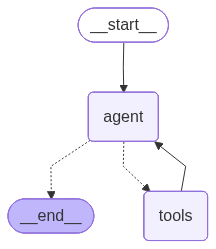

In [ ]:
from langgraph.prebuilt import create_react_agent

research_agent = create_react_agent(
    model = llm,
    tools = [web_search, internal_tool_1],
    prompt = (
        "You are a research agent. \n\n"
        "Instructions: \n"
        "Assist only with research related task, respind to the supervisor directly \n"
        "Respond only with the results of your work do not include any other text"
    ),
    name = "research agent"
)

research_agent

/var/folders/58/7rk_l2gn3lv73f_nlj98yjgc0000gn/T/ipykernel_4136/2243745222.py:17: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  math_agent = create_react_agent(


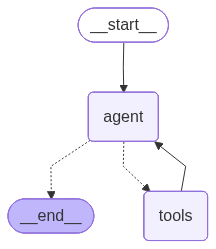

In [28]:
# Functions for the maths agent

def add(a : float , b : float) :
    """ Add two numbers  """
    return a+b

def multiply(a : float, b : float) :
    """ Multiply two numbers """
    return a*b

def divide(a : float, b : float) :
    """ Divide two numbers """
    return a/b



math_agent = create_react_agent(
    model = llm,
    tools = [add,multiply, divide],
    prompt = (
        "You are a math agent. \n\n"
        "Instructions :  \n"
        "- Assist only with math related task \n"
        "After you are done with tasks, respond to the supervisor directly\n"
        "- Respond only with the results of your work, don't include any other text."
    ),
    name = "math_agent"

)

math_agent

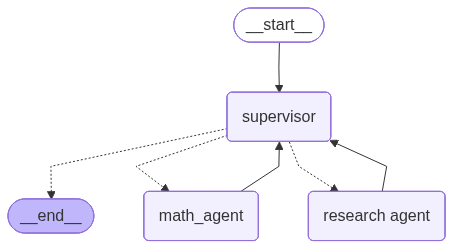

In [36]:
# making the supervisor agent

from langgraph_supervisor import create_supervisor

supervisor = create_supervisor(
    model = llm,
    agents = [research_agent, math_agent],
    prompt = (
    "You are a supervisor managing two agents : \n"
    "- a research_agent. Assign research related tasks to this agent \n"
    "- a math agent. Assign math related task to this agent \n"
    "Assign work to one agent at a time, do not call agent in parallel. \n"
    "Don't do any work yourself"
    ),
    add_handoff_back_messages=  True,
    output_mode = "full_history"
).compile()

supervisor

In [37]:
response  = supervisor.invoke({"messages" : "list all the transformes varients in the production deployments from the retriever and then tell me what is 5 plus 10"})


Using tool : retriever_tool


In [39]:
response

{'messages': [HumanMessage(content='list all the transformes varients in the production deployments from the retriever and then tell me what is 5 plus 10', additional_kwargs={}, response_metadata={}, id='7d76b698-b90b-4fde-882b-3de5375386e3'),
  AIMessage(content=[{'text': "I'll help you with both tasks. Let me start by asking the research agent to find information about the transformer variants in production deployments from the retriever.", 'type': 'text'}, {'id': 'toolu_01CWDjgmjbkciPdaHHpQzGwY', 'input': {'task': 'List all the transformer variants in the production deployments from the retriever'}, 'name': 'transfer_to_research_agent', 'type': 'tool_use', 'caller': {'type': 'direct'}}], additional_kwargs={}, response_metadata={'id': 'msg_014vWna69fuqgcWvD2DphE5U', 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cach

In [43]:
print(response["messages"][-1].content)


## Summary:

**Transformer Variants in Production Deployments:**
1. **EfficientFormer** - Raspberry Pi 4 deployment
2. **Longformer** - Customer support logs (8K tokens)
3. **Reformer** - LSH attention mechanism
4. **TinyBERT** - Support ticket classification
5. **LLaMA2** - RAG-integrated chatbot
6. **FlashAttention2** - Integrated into LLaMA2

**5 plus 10 = 15**
